# 04 - CNN Baseline

## AI-Powered Runway FOD Detection & Safety Alert System

### Objective

Before moving to object detection, we will build a simple CNN baseline.

The purpose of this notebook is **not** to create the final FOD detection
system.

We will use the CNN to understand:

- How images are prepared for a neural network
- How a CNN learns visual features
- How FOD classes can be classified
- Training and validation loss
- Training and validation accuracy
- Basic model evaluation
- Why image classification alone is not enough for the final project

### Important

The final project is an **object detection** problem because we need to
identify the FOD object and its location.

This CNN is therefore a **baseline experiment** before object detection.


## 1. Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image


## 2. Check PyTorch and GPU

In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)


PyTorch version: 2.14.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Using device: cuda


## 3. Project Paths

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "FODPascalVOCFormat-V.2.1"
    / "VOC2007"
)

IMAGE_DIR = DATA_ROOT / "JPEGImages"

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "fod_annotations.csv"
)

print("Image directory:", IMAGE_DIR)
print("Annotation file:", PROCESSED_DATA_PATH)


Image directory: d:\Projects\AI Runway FOD Detection\data\raw\FODPascalVOCFormat-V.2.1\VOC2007\JPEGImages
Annotation file: d:\Projects\AI Runway FOD Detection\data\processed\fod_annotations.csv


## 4. Load Annotation Data

In [4]:
df = pd.read_csv(PROCESSED_DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (34472, 25)


,image_id,filename,image_path,annotation_path,split,width,height,class_name,xmin,ymin,...,pose,track_id,keyframe,weather_label,light_label,image_exists,x_center,y_center,box_width,box_height
0,0,000000.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2219,104.2833,...,Unspecified,0,True,Wet,Dim,True,0.482771,0.421051,0.044062,0.14688
1,1,000001.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2422,104.7611,...,Unspecified,0,False,Wet,Dim,True,0.482841,0.422644,0.044068,0.14688
2,2,000002.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2641,105.2389,...,Unspecified,0,False,Wet,Dim,True,0.482911,0.424236,0.044062,0.14688
3,3,000003.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.2844,105.7167,...,Unspecified,0,False,Wet,Dim,True,0.482979,0.425829,0.044063,0.14688
4,4,000004.jpg,D:\Projects\AI Runway FOD Detection\data\raw\F...,D:\Projects\AI Runway FOD Detection\data\raw\F...,trainval,300,300,Battery,138.3047,106.1945,...,Unspecified,0,False,Wet,Dim,True,0.483047,0.427417,0.044062,0.14687


## 5. Prepare Data for Classification

For this CNN baseline, each training example will be an **individual FOD
object crop**.

For example, if an image contains:

- Battery
- Screw
- Rock

we crop each annotated object separately.

The CNN will then learn to classify the cropped object.

This is different from the final object-detection task.


## 6. Keep Only Valid Training/Test Records

In [5]:
# Remove records without an official trainval/test split
classification_df = df[
    df["split"].isin(["trainval", "test"])
].copy()

# Keep only rows whose image exists
classification_df = classification_df[
    classification_df["image_exists"] == True
].copy()

print("Rows available for CNN baseline:", len(classification_df))
print("Unique images:", classification_df["image_id"].nunique())
print("Classes:", classification_df["class_name"].nunique())


Rows available for CNN baseline: 34402
Unique images: 33723
Classes: 31


## 7. Create a Fixed Class Mapping

A neural network needs class labels represented as numbers.

For example:

`Battery → 0`

`Bolt → 1`

`Rock → 2`

The exact numbers do not carry meaning. They are simply class IDs.


In [6]:
classes = sorted(classification_df["class_name"].unique())

class_to_id = {
    class_name: index
    for index, class_name in enumerate(classes)
}

id_to_class = {
    index: class_name
    for class_name, index in class_to_id.items()
}

NUM_CLASSES = len(classes)

print("Number of classes:", NUM_CLASSES)
print()

for class_id, class_name in id_to_class.items():
    print(class_id, "->", class_name)


Number of classes: 31

0 -> AdjustableClamp
1 -> AdjustableWrench
2 -> Battery
3 -> Bolt
4 -> BoltNutSet
5 -> BoltWasher
6 -> ClampPart
7 -> Cutter
8 -> FuelCap
9 -> Hammer
10 -> Hose
11 -> Label
12 -> LuggagePart
13 -> LuggageTag
14 -> MetalPart
15 -> MetalSheet
16 -> Nail
17 -> Nut
18 -> PaintChip
19 -> Pen
20 -> PlasticPart
21 -> Pliers
22 -> Rock
23 -> Screw
24 -> Screwdriver
25 -> SodaCan
26 -> Tape
27 -> Washer
28 -> Wire
29 -> Wood
30 -> Wrench


## 8. Create Train and Validation Data

The FOD-A files provide `trainval` and `test`.

For the CNN baseline, we need a validation set during training.

We will create validation data from the `trainval` portion.

The split is performed at the **image level**, so annotations from the same
image do not get separated between train and validation.


In [7]:
from sklearn.model_selection import train_test_split

trainval_images = (
    classification_df[
        classification_df["split"] == "trainval"
    ]["image_id"]
    .drop_duplicates()
    .tolist()
)

train_images, val_images = train_test_split(
    trainval_images,
    test_size=0.20,
    random_state=42
)

train_df = classification_df[
    classification_df["image_id"].isin(train_images)
].copy()

val_df = classification_df[
    classification_df["image_id"].isin(val_images)
].copy()

test_df = classification_df[
    classification_df["split"] == "test"
].copy()

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", test_df["image_id"].nunique())

print()
print("Training annotation rows:", len(train_df))
print("Validation annotation rows:", len(val_df))
print("Test annotation rows:", len(test_df))


Training images: 20235
Validation images: 5059
Test images: 8429

Training annotation rows: 20613
Validation annotation rows: 5176
Test annotation rows: 8613


## 9. Create the FOD Crop Dataset

We will create a PyTorch `Dataset`.

For every annotation:

1. Load the original image.
2. Read the bounding box.
3. Crop the FOD object.
4. Resize the crop to a fixed size.
5. Convert it to a tensor.
6. Return the image crop and class ID.


In [8]:
class FODCropDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        class_to_id,
        image_size=(128, 128)
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.class_to_id = class_to_id
        self.image_size = image_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = self.image_dir / row["filename"]

        image = Image.open(image_path).convert("RGB")

        xmin = int(row["xmin"])
        ymin = int(row["ymin"])
        xmax = int(row["xmax"])
        ymax = int(row["ymax"])

        image_width, image_height = image.size

        xmin = max(0, min(xmin, image_width - 1))
        ymin = max(0, min(ymin, image_height - 1))
        xmax = max(xmin + 1, min(xmax, image_width))
        ymax = max(ymin + 1, min(ymax, image_height))

        crop = image.crop((xmin, ymin, xmax, ymax))

        crop = crop.resize(self.image_size)

        image_array = np.array(crop).astype(np.float32) / 255.0

        image_tensor = torch.tensor(
            image_array,
            dtype=torch.float32
        ).permute(2, 0, 1)

        label = self.class_to_id[row["class_name"]]

        return image_tensor, label


## 10. Create DataLoaders

In [9]:
train_dataset = FODCropDataset(
    train_df,
    IMAGE_DIR,
    class_to_id
)

val_dataset = FODCropDataset(
    val_df,
    IMAGE_DIR,
    class_to_id
)

test_dataset = FODCropDataset(
    test_df,
    IMAGE_DIR,
    class_to_id
)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Training batches: 323
Validation batches: 81
Test batches: 135


## 11. Inspect One Batch

In [10]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First labels:", labels[:10])


Image batch shape: torch.Size([64, 3, 128, 128])
Label batch shape: torch.Size([64])
First labels: tensor([20, 13,  7, 18,  9, 13,  3, 28, 11,  7])


## 12. Visualize Training Crops

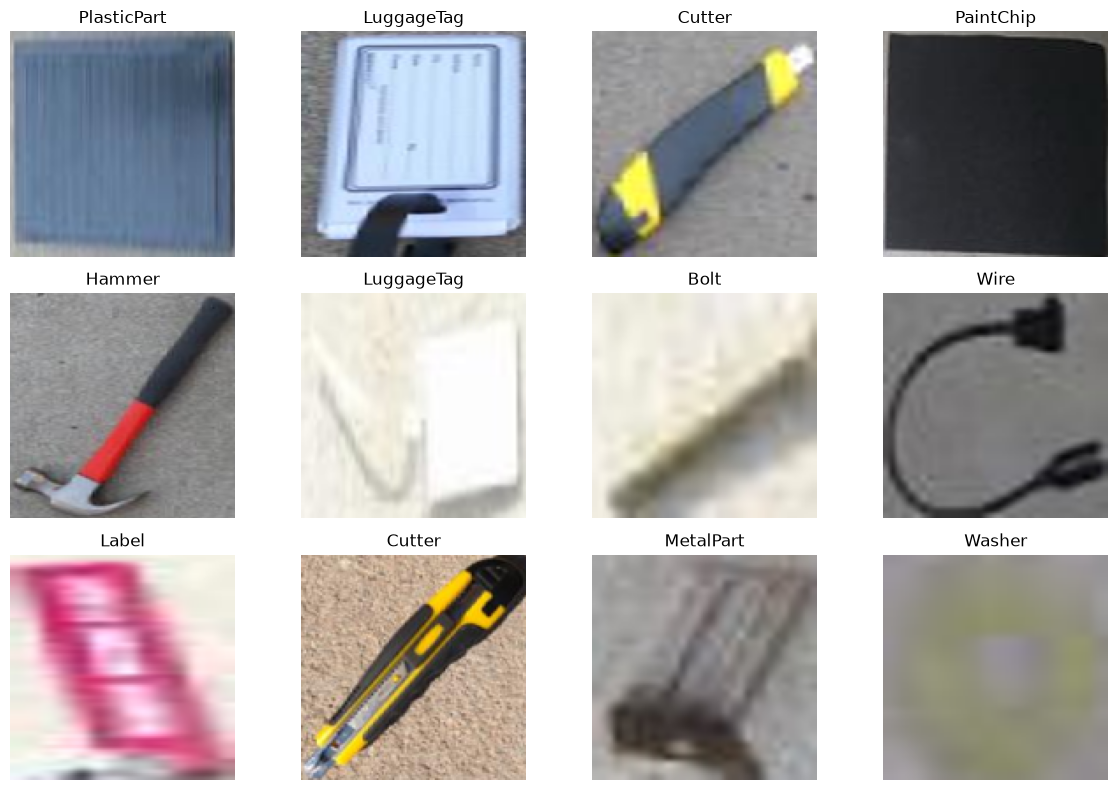

In [11]:
plt.figure(figsize=(12, 8))

for i in range(12):

    image = images[i].permute(1, 2, 0).numpy()
    label = labels[i].item()

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(id_to_class[label])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 13. Build a Simple CNN

The CNN will contain:

- Convolution layers
- ReLU activation
- Max Pooling
- Fully connected layers

The purpose is to create a simple baseline, not a highly optimized model.


In [12]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 16 * 16,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


## 14. Create the Model

In [13]:
model = SimpleCNN(NUM_CLASSES)

model = model.to(DEVICE)

print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=31, bias=True)
  )
)


## 15. Loss Function and Optimizer

For multi-class classification:

- Loss function: Cross Entropy Loss
- Optimizer: Adam

The model will try to reduce the classification error during training.


In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


## 16. Training Function

In [15]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


## 17. Validation Function

In [16]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


## 18. Train the CNN

For the first baseline experiment, we will use a small number of epochs.

This gives us a quick understanding of the training behavior before moving
to the much more important object-detection model.


In [17]:
EPOCHS = 5

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


Epoch 1/5 | Train Loss: 0.8296 | Train Acc: 0.7691 | Val Loss: 0.1316 | Val Acc: 0.9604
Epoch 2/5 | Train Loss: 0.1312 | Train Acc: 0.9614 | Val Loss: 0.0588 | Val Acc: 0.9830
Epoch 3/5 | Train Loss: 0.0808 | Train Acc: 0.9753 | Val Loss: 0.0296 | Val Acc: 0.9911
Epoch 4/5 | Train Loss: 0.0521 | Train Acc: 0.9840 | Val Loss: 0.0403 | Val Acc: 0.9890
Epoch 5/5 | Train Loss: 0.0580 | Train Acc: 0.9835 | Val Loss: 0.0161 | Val Acc: 0.9950


## 19. Plot Training and Validation Loss

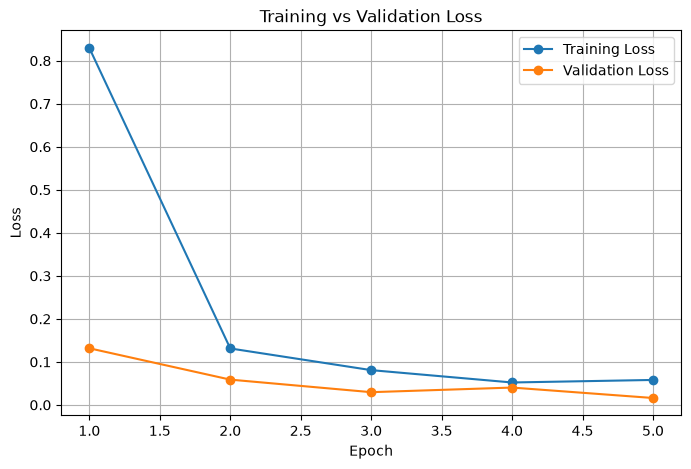

In [18]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


## 20. Plot Training and Validation Accuracy

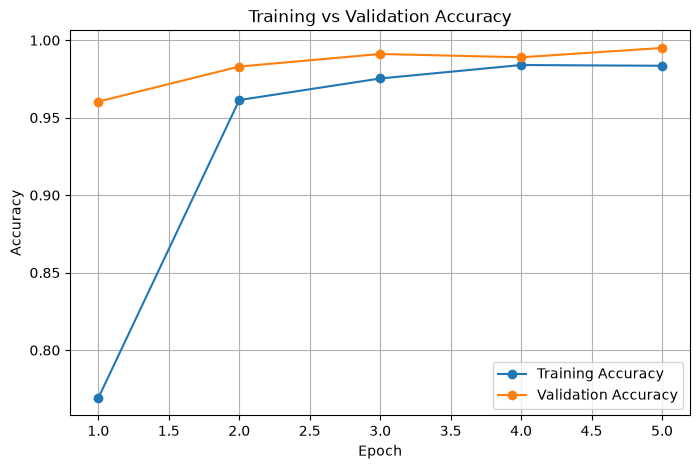

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()


## 21. Evaluate the CNN on the Test Set

The official FOD-A test split is kept separate from training and validation.

We will calculate the basic classification accuracy here.


In [20]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.025597599038829653
Test Accuracy: 0.9936143039591315


## 22. Check Sample Predictions

Let's see what the CNN predicts for a few test crops.


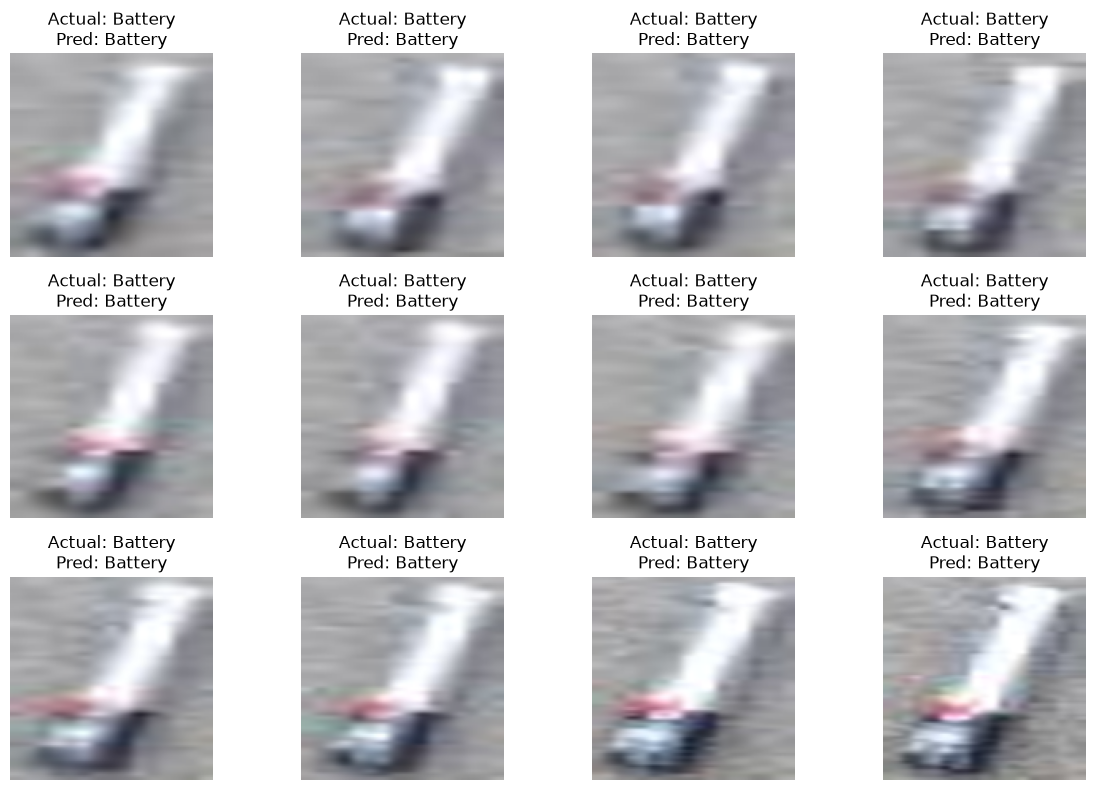

In [21]:
model.eval()

test_images, test_labels = next(iter(test_loader))

test_images = test_images.to(DEVICE)

with torch.no_grad():

    outputs = model(test_images)

    predictions = outputs.argmax(dim=1)

test_images_cpu = test_images.cpu()
predictions_cpu = predictions.cpu()
test_labels_cpu = test_labels.cpu()

plt.figure(figsize=(12, 8))

for i in range(12):

    image = test_images_cpu[i].permute(1, 2, 0).numpy()

    actual_class = id_to_class[test_labels_cpu[i].item()]
    predicted_class = id_to_class[predictions_cpu[i].item()]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(
        f"Actual: {actual_class}\n"
        f"Pred: {predicted_class}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## 23. Why This CNN Is Only a Baseline

This CNN receives a **cropped FOD object**.

That means we already know where the object is.

In the real runway scenario, the system receives the complete image and must
answer two questions:

1. **Where is the FOD?**
2. **What type of FOD is it?**

A normal image-classification CNN does not directly provide the object's
location.

Therefore, the next major step is **object detection**.


## 24. Classification vs Object Detection

### Image Classification

Input:

`Runway image`

Output:

`FOD class`

Example:

`Battery`

It does not tell us the exact location.

### Object Detection

Input:

`Runway image`

Output:

`Class + Bounding Box + Confidence`

Example:

`Battery + [x1, y1, x2, y2] + 0.94`

This is what our final project needs.


## 25. Baseline Conclusion

The CNN baseline gives us a reference point for FOD image classification.

We have now covered:

- PyTorch dataset creation
- FOD object cropping
- Train/validation/test split
- CNN architecture
- Convolution
- ReLU
- Max Pooling
- Fully connected layers
- Cross Entropy Loss
- Adam optimizer
- GPU training
- Training/validation curves
- Test evaluation
- Sample predictions

### Important project decision

We will **not** treat this CNN classifier as the final solution.

The final system will move to object detection so that the model can detect
FOD objects directly inside runway/taxiway images.

### Next notebook

`05_Object_Detection.ipynb`

This is where we move from a CNN classification baseline to actual FOD
object detection.
